#### Preprocessing code

Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [4]:
from __future__ import annotations
import os
from pathlib import Path
from datetime import datetime
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import notebook_setup
info = notebook_setup.setup()
# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
from concurrent.futures import ProcessPoolExecutor, as_completed

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


In [5]:
#import local yaml for env preset variables
from analysis_config_loader import load_analysis_config  # new import
config_path = "analysis_config.yaml"  # adjust as needed
analysis_config = load_analysis_config(config_path)

In [6]:
type(analysis_config)
analysis_config
stage_names = analysis_config.task_phase_names
stage_cols =  stage_names
stage_names


['Early_IA_Error',
 'Early_IA_Correct',
 'Late_IA',
 'Early_RS_Error',
 'Early_RS_Correct',
 'Late_RS']

#### Define dataset methods

In [7]:
#set parameters
data_type_used = "calcium_spikes" #OR, 'dff'
run_activity_enrichment = True
export_mean_active = True
use_WT_CLNZ_folder = False
phase_type = analysis_config.phase_division_types[1]  # 'complex', early vs late and correct vs error
print(phase_type)
# set up locations for input/output #get where to load data 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
print(root_dir)
os.chdir(root_dir)
data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')

#make analysis folder 
hour_str = datetime.now().strftime("%H")

storage_folder_name = root_dir / Path(f"processed_{data_type_used}")
print(storage_folder_name)
storage_folder_name.mkdir(parents=True, exist_ok=True)


complex
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\processed_calcium_spikes


In [9]:
## Matlab file handling functions:
import h5py

def check_corrupted_files(failed_files):
    # Optional Investigate corrupted files
    print("="*70)
    print("INVESTIGATING CORRUPTED FILES")
    print("="*70)

    if len(failed_files) == 0:
        print("No failed files to investigate.")
        return
    
    for fname in failed_files:
        filepath = source_dataset_location / fname
        
        print(f"\n📁 {fname}")
        print("-" * 70)
        
        if not filepath.exists():
            print("   File does not exist!")
            continue
        
        # Check file size
        size_bytes = filepath.stat().st_size
        size_kb = size_bytes / 1024
        size_mb = size_kb / 1024
        
        print(f"  Size: {size_bytes:,} bytes ({size_mb:.2f} MB)")
        
        # Read first bytes to check file signature
        with open(filepath, 'rb') as f:
            header = f.read(100)
        
        # Check for MATLAB file signatures
        print(f"  First 20 bytes (hex): {header[:20].hex()}")
        
        # HDF5 files should start with \x89HDF\r\n\x1a\n
        if header[:4] == b'\x89HDF':
            print("  ✓ Valid HDF5 signature")
        elif header[:4] == b'MATL':
            print("  ⚠️ Old MATLAB format (v5/v6) - needs scipy.io")
        else:
            print(f"   Unknown file signature - file may be corrupted")
            print(f"     Expected: b'\\x89HDF' or b'MATL'")
            print(f"     Got: {header[:4]}")
        
        # Try to detect if file is truncated
        if size_mb < 1:
            print(f"  ⚠️ WARNING: File is unusually small ({size_mb:.2f} MB)")

    # Compare with a working file
    print("\n" + "="*70)
    print("COMPARISON WITH WORKING FILES:")

    # Get file sizes of all working files
    working_sizes = []
    for obj in loaded_objects[:5]:
        fname = obj['name'] + '_dataset_object.mat'
        fpath = source_dataset_location / fname
        if fpath.exists():
            size_mb = fpath.stat().st_size / 1024 / 1024
            working_sizes.append(size_mb)
            print(f"  {fname}: {size_mb:.2f} MB")

    if working_sizes:
        avg_size = sum(working_sizes) / len(working_sizes)
        print(f"\n  Average working file size: {avg_size:.2f} MB")

def load_matlab_object(filepath):
    """Load MATLAB dataset_with_spatial_ROI object from .mat file"""
    # Parse metadata from filename
    filename = filepath.stem.replace('_dataset_object', '')
    parts = filename.split('_')
    
    # Extract name, geno from filename (e.g., "10_3_HET_RS1")
    name = filename
    if len(parts) >= 3:
        geno = parts[2]  # HET or WT
        session = parts[3] if len(parts) > 3 else 'RS1'
    else:
        geno = "UNKNOWN"
        session = "RS1"
    
    try:
        with h5py.File(filepath, 'r') as f:            # Load numeric data from known datasets
            raster = f['#refs#']['i'][()]  # (time, cells)
            # Get deduplicated flag from group x
            deduplicated = f['#refs#']['x']['deduplicated'][0, 0] if 'deduplicated' in f['#refs#']['x'] else False
            # Create object dictionary
            obj = {
                'name': name,
                'geno': geno,
                'session': session,
                'geno_day': None,  # Will need to be set externally if needed
                'raster': raster.T,  # Transpose to (cells, time)
                'deduplicated': bool(deduplicated),
                'good_cells': f['#refs#']['k'][()] if 'k' in f['#refs#'] else None,  # Cell IDs
                'labels': f['#refs#']['j'][()] if 'j' in f['#refs#'] else None,  # Trial/time info
            }
            # Load spatial info if present
            if 'n' in f['#refs#']:
                spatial = f['#refs#']['n']
                obj['spatial_weights'] = spatial['spatial_weights'][()] if 'spatial_weights' in spatial else None
                obj['temporal_weights'] = spatial['temporal_weights'][()] if 'temporal_weights' in spatial else None
                obj['user_labels'] = spatial['user_labels'][()] if 'user_labels' in spatial else None
                obj['subject_name'] = spatial['subject_name'][()] if 'subject_name' in spatial else None
            
            return obj
    
    except (OSError, KeyError) as e:
        print(f"  ERROR loading {filepath.name}: {e}")
        return None


In [10]:
#get all dataset names
#verify you are using the correct number of dataset 
source_dataset_location = Path(r"C:\Users\13car\Dropbox\UCSF\vikaas\Ruleshifting task notes\dlx mice notes\All datasets- Padded Labels, raster, EXTRACT outputs\dataset_objects")
content_names = [f for f in source_dataset_location.glob('**/*') if "object" in f.name]
print(f"Found {len(content_names)} files in {source_dataset_location}")
for file in content_names:
    print(file.name)

assert len(content_names) == 35, "Number of datasets does not match expected"

Found 35 files in C:\Users\13car\Dropbox\UCSF\vikaas\Ruleshifting task notes\dlx mice notes\All datasets- Padded Labels, raster, EXTRACT outputs\dataset_objects
10_3_HET_RS1_dataset_object.mat
10_3_HET_RS2_dataset_object.mat
10_3_HET_RS3_dataset_object.mat
13_3_HET_RS1_dataset_object.mat
13_3_HET_RS2_dataset_object.mat
13_3_HET_RS3_dataset_object.mat
13_4_WT_RS1_dataset_object.mat
13_4_WT_RS2_dataset_object.mat
13_5_HET_RS1_dataset_object.mat
13_5_HET_RS2_dataset_object.mat
13_5_HET_RS3_dataset_object.mat
13_6_WT_RS1_dataset_object.mat
13_6_WT_RS2_dataset_object.mat
13_8_HET_RS1_dataset_object.mat
13_8_HET_RS2_dataset_object.mat
13_8_HET_RS3_dataset_object.mat
14_2_WT_RS1_dataset_object.mat
14_2_WT_RS2_dataset_object.mat
15_1_HET_RS1_dataset_object.mat
15_1_HET_RS2_dataset_object.mat
15_1_HET_RS3_dataset_object.mat
5_3_WT_RS1_dataset_object.mat
5_3_WT_RS2_dataset_object.mat
6_2_WT_RS1_dataset_object.mat
6_2_WT_RS2_dataset_object.mat
7_2_WT_RS1_dataset_object.mat
7_4_WT_RS1_dataset_obje

In [11]:
# Load all files with error handling
loaded_objects = []
failed_files = []

for num, file in enumerate(content_names):
    print(f"Loading file {num}/{len(content_names)}: {file.name}")
    obj = load_matlab_object(file)
    if obj is None:
        failed_files.append(file.name)
        print(f"  SKIPPED\n")
        continue
    loaded_objects.append(obj)
    print(f"  {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames")
print(f"\n SUMMARY: Successfully loaded {len(loaded_objects)}/{len(content_names)} files")

if failed_files:
    print(f"\n Failed files ({len(failed_files)}):")
    for fname in failed_files:
        print(f"  - {fname}")
check_corrupted_files(failed_files)

Loading file 0/35: 10_3_HET_RS1_dataset_object.mat
  10_3_HET_RS1: 136 cells × 150415 frames
Loading file 1/35: 10_3_HET_RS2_dataset_object.mat
  10_3_HET_RS2: 168 cells × 97940 frames
Loading file 2/35: 10_3_HET_RS3_dataset_object.mat
  10_3_HET_RS3: 157 cells × 108794 frames
Loading file 3/35: 13_3_HET_RS1_dataset_object.mat
  13_3_HET_RS1: 160 cells × 191533 frames
Loading file 4/35: 13_3_HET_RS2_dataset_object.mat
  13_3_HET_RS2: 145 cells × 108651 frames
Loading file 5/35: 13_3_HET_RS3_dataset_object.mat
  13_3_HET_RS3: 147 cells × 128277 frames
Loading file 6/35: 13_4_WT_RS1_dataset_object.mat
  13_4_WT_RS1: 183 cells × 153831 frames
Loading file 7/35: 13_4_WT_RS2_dataset_object.mat
  13_4_WT_RS2: 171 cells × 106245 frames
Loading file 8/35: 13_5_HET_RS1_dataset_object.mat
  13_5_HET_RS1: 120 cells × 229350 frames
Loading file 9/35: 13_5_HET_RS2_dataset_object.mat
  13_5_HET_RS2: 125 cells × 141283 frames
Loading file 10/35: 13_5_HET_RS3_dataset_object.mat
  13_5_HET_RS3: 131 cel

<Axes: >

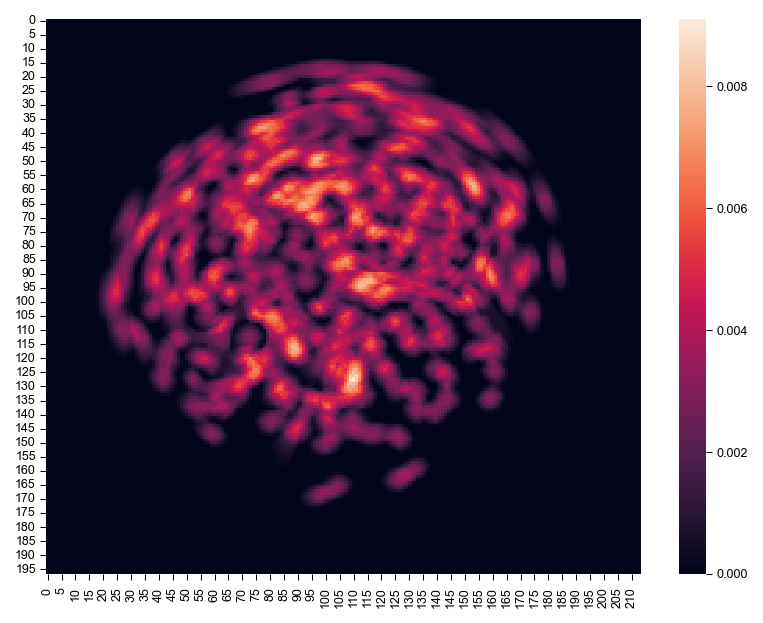

In [12]:
sns.heatmap(np.mean(obj['spatial_weights'], axis=0))

#### Import canonical dataset used in paper

In [13]:
# import canonical ensemble matrix previously created in MATLAB, used for paper #find old file- 
canonical_file = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")
canonical_data = pd.read_parquet(canonical_file)
print(canonical_data.info())
canonical_data.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 93253 entries, 0 to 116376
Data columns (total 93 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   task_phase_vec     93253 non-null  object 
 1   IA_RS_vec          93253 non-null  object 
 2   corr_err_vec       93253 non-null  object 
 3   trial_num          93253 non-null  int64  
 4   neuron_ID          93253 non-null  int64  
 5   name               93253 non-null  object 
 6   day                93253 non-null  int32  
 7   geno               93253 non-null  object 
 8   geno_day           93253 non-null  object 
 9   -3.0s to -2.75s    93253 non-null  float64
 10  -2.75s to -2.5s    93253 non-null  float64
 11  -2.5s to -2.25s    93253 non-null  float64
 12  -2.25s to -2.0s    93253 non-null  float64
 13  -2.0s to -1.75s    93253 non-null  float64
 14  -1.75s to -1.5s    93253 non-null  float64
 15  -1.5s to -1.25s    93253 non-null  float64
 16  -1.25s to -1.0s    93253 n

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,name,day,geno,geno_day,-3.0s to -2.75s,...,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial
0,Early_IA_Correct,IA,Correct,1,1,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.0,False
2,Early_IA_Correct,IA,Correct,1,3,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-3,1.0,0.0,False
3,Early_IA_Correct,IA,Correct,1,4,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,1.0,0.0,0.0,False,1.0,10_3_HET_RS1-4,1.0,0.0,False


In [14]:
#get ensemble info from canon df
canon_ensembles  = canonical_data.groupby(by = ['unique_ID', 'geno', 'geno_day'])[stage_cols].first()
canon_ensembles.tail(3)

,,,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
unique_ID,geno,geno_day,,,,,,
9_3_HET_RS3-97,HET,Het postCLNZ,1.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-98,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-99,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0


### Extract and Transform Matlab Objects into stage-labeled dataframes

#### E- dataset objs to dataframes, T- add task stage cols

In [15]:
def dataset_obj_to_df(dataset_obj):
    # Create DataFrame from raster (cells × frames)
    print(f"Processing {dataset_obj['name']}: {dataset_obj['raster'].nbytes} bytes")
    #setup dataset df 
    raster_df = pd.DataFrame(
        dataset_obj['raster'].T,
        index=[f'frame_{i}' for i in range(dataset_obj['raster'].shape[1])],
        columns = [f'cell_{i}' for i in range(dataset_obj['raster'].shape[0])],
        dtype = 'Sparse[int]')
            #add labels
    raster_df['labels'] = dataset_obj['labels']
    # Add metadata columns
    #cell Id is represented as col name 
    raster_df['subject_name'] = dataset_obj['name']
    raster_df['geno'] = dataset_obj['geno']
    raster_df['session'] = dataset_obj['session']
    
    return raster_df
#test 1 dataset
test_df = dataset_obj_to_df(loaded_objects[0])
print(test_df.info())
test_df.tail(3)

Processing 10_3_HET_RS1: 163651520 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 150415 entries, frame_0 to frame_150414
Columns: 140 entries, cell_0 to session
dtypes: Sparse[int32, 0](136), float64(1), object(3)
memory usage: 12.5+ MB
None


,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,...,cell_130,cell_131,cell_132,cell_133,cell_134,cell_135,labels,subject_name,geno,session
frame_150412,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150413,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1


In [16]:
from trial_detection import return_trial_num_at_frame, build_phase_masks, get_trial_stage_map, get_inRS_isError

def add_task_stage_to_raster_df(raster_df, analysis_config):
    """ Joins all the trial stage functions into one function for ease of use (function imported elsewhere).2s per raster 
    #workflow: 
        # 1) Call "trial num at frame" function
        # 2. Add trial number to raster_df
        # 3. drop frames that are not in a trial
        # 4. Add task stage to raster_df based off trial number at frame
    """
    stage_names = analysis_config.task_phase_names
    # 1. Transform frame label vector into trial vector
    labels = raster_df['labels']
    trial_num_at_frame, _, num_trials = return_trial_num_at_frame(labels)
    raster_df.loc[:, 'trial_num'] = trial_num_at_frame 

    # 2. Add trial number to raster_df
    raster_df = raster_df[raster_df['trial_num'] > 0].copy() #  dropping trial_num == 0
    # 4. Add task stage to raster_df based off trial number at frame
    stage_dict = build_phase_masks(labels,analysis_config)
    #5. map trial num to stage
    trial_stage_map = get_trial_stage_map(stage_dict, stage_names, num_trials)
    raster_df.loc[:, 'task_stage'] = raster_df['trial_num'].map(trial_stage_map)
    return raster_df

In [17]:
def label_frame_sections_df(df: pd.DataFrame, label_col: str,*, section_names=("pre_outcome", "post_outcome", "ITI")):
    """
    Vectorized: assign each frame one of {pre_outcome, post_outcome, ITI}. Tie-breaks at 4 (IA) and 11 (RS) go to post_outcome (overwrite order).

    Parameters
    ----------
    df : DataFrame with one row per frame
    label_col : name of column holding per-frame integer labels
    section_names : (pre_outcome, post_outcome, ITI)

    Returns
    -------
    pd.Series (object) of section names aligned to df.index
    """
    pre_outcome, post_outcome, iti = section_names
    labels = df[label_col].to_numpy()
    out = np.full(labels.shape[0], None, dtype=object)

    # IA ranges (2–8)
    ia_pre  = (labels >= 2)  & (labels <= 4)     # pre_outcome
    ia_post = (labels >= 4)  & (labels <= 7)     # post_outcome (overwrites label==4)
    ia_iti  = (labels == 8)                      # ITI

    # RS ranges (9–15)
    rs_pre  = (labels >= 9)  & (labels <= 11)    # pre_outcome
    rs_post = (labels >= 11) & (labels <= 14)    # post_outcome (overwrites label==11)
    rs_iti  = (labels == 15)                     # ITI

    # Overwrite order preserves “boundary goes to later section”:
    out[ia_pre  | rs_pre]  = pre_outcome
    out[ia_post | rs_post] = post_outcome
    out[ia_iti  | rs_iti]  = iti

    return out

In [18]:
# Loop over imported subject rasters and create pandas DataFrames
raster_dataframes = {}

for obj in loaded_objects:    # Create DataFrame from raster (cells × frames)
    raster_df = dataset_obj_to_df(obj)
    raster_df = add_task_stage_to_raster_df(raster_df, analysis_config)
    raster_df['trial_section'] = label_frame_sections_df(raster_df, 'labels', section_names=analysis_config.trial_section_names) #annotate pre,post,ITI

    raster_dataframes[obj['name']] = raster_df
print(f"\nTotal DataFrames created: {len(raster_dataframes)}")

Processing 10_3_HET_RS1: 163651520 bytes
Processing 10_3_HET_RS2: 131631360 bytes
Processing 10_3_HET_RS3: 136645264 bytes
Processing 13_3_HET_RS1: 245162240 bytes
Processing 13_3_HET_RS2: 126035160 bytes
Processing 13_3_HET_RS3: 150853752 bytes
Processing 13_4_WT_RS1: 225208584 bytes
Processing 13_4_WT_RS2: 145343160 bytes
Processing 13_5_HET_RS1: 220176000 bytes
Processing 13_5_HET_RS2: 141283000 bytes
Processing 13_5_HET_RS3: 101650760 bytes
Processing 13_6_WT_RS1: 407216056 bytes
Processing 13_6_WT_RS2: 286371552 bytes
Processing 13_8_HET_RS1: 205506288 bytes
Processing 13_8_HET_RS2: 184071712 bytes
Processing 13_8_HET_RS3: 247363296 bytes
Processing 14_2_WT_RS1: 158077680 bytes
Processing 14_2_WT_RS2: 170570944 bytes
Processing 15_1_HET_RS1: 209435040 bytes
Processing 15_1_HET_RS2: 185898360 bytes
Processing 15_1_HET_RS3: 133253480 bytes
Processing 5_3_WT_RS1: 198030360 bytes
Processing 5_3_WT_RS2: 211466640 bytes
Processing 6_2_WT_RS1: 212864136 bytes
Processing 6_2_WT_RS2: 19240

#### T- add task stage + metadata to subject dfs

In [19]:
raster_df

,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,...,cell_212,cell_213,cell_214,labels,subject_name,geno,session,trial_num,task_stage,trial_section
frame_15007,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15008,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15009,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15010,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15011,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_205895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205898,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI


In [20]:
def plot_task_stages(stage_dict, stage_cols, fig_size = (10, 7)):
    # Define stage_cols from the stage_dict keys (excluding internal keys starting with '_')
    stage_cols = [k for k in stage_dict.keys() if not k.startswith('_')]
    # Fix variable name: use 'axes' consistently, and squeeze data to handle shape (38,1) -> (38,)
    fig, axes = plt.subplots(len(stage_cols), 1, figsize = fig_size, layout = 'constrained')
    for index, s in enumerate(stage_cols):
        # Reshape to column vector for proper heatmap display
        data =  stage_dict[s].reshape(1, -1)
        sns.heatmap(ax = axes[index], data = data, cbar = False,  cmap = 'viridis')
        axes[index].set_title(s)

plot_task_stages(stage_dict, stage_cols)

NameError: name 'stage_dict' is not defined

In [40]:

print(raster_df.trial_section.unique())
print(raster_df.task_stage.unique())
raster_df

['pre_outcome' 'post_outcome' 'ITI' None]
['Early_IA_Correct' 'Early_IA_Error' 0 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']


,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,...,cell_212,cell_213,cell_214,labels,subject_name,geno,session,trial_num,task_stage,trial_section
frame_15007,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15008,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15009,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15010,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15011,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_205895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205898,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI


### Run activity enrichment analysis

### Circular shuffle of frame labels 

In [ ]:
## given task stage, create N label permuted versions and 

# matlab code flow:
# + create matrix (n_cells x N_shuffles), where elem at (i,j) = random frame offset for cell i at shuffle j 
# + for each shuffle, apply offset to (frame labels of interest) vector, with cells having independent offsets 
# + for each cell, calculate mean activity in offset frames 
# + calculate p-value for each cell

In [96]:
def get_frames_of_interest(raster_df, trial_section= 'post_outcome', task_stage= 'Late_RS'):
    """ Returns frames of interest for specific trial section (e.g. pre, post, ITI) and specific task stage (e.g. Late RS,or IA) """
    # bool_frames_of_interest : boolean series, with index = string of frame number and true if frame is of interest    
    bool_frames_of_interest = (raster_df['trial_section'] == trial_section) & (raster_df['task_stage'] == task_stage)
    # reset index to be numeric vals only, referencing what row in raster_df the bool_frames_of_interest are in
    bool_index_of_interest = bool_frames_of_interest.reset_index(drop = True)
    #use boolean indexing to get the row indices of the true values
    indices_of_true_values = bool_index_of_interest[bool_index_of_interest.values].index.values
    return indices_of_true_values


    

In [97]:
raster_df

,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,...,cell_212,cell_213,cell_214,labels,subject_name,geno,session,trial_num,task_stage,trial_section
frame_15007,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15008,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15009,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15010,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15011,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_205895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205898,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI


In [106]:
bool_frames_of_interest = get_frames_of_interest(raster_df)
bool_frames_of_interest

array([171860, 171861, 171862, ..., 187417, 187418, 187419], dtype=int64)

In [107]:
# I want to take the indices of the true values which == the right task stage x trial section combo, which will be the indices of the frames of interest.
bool_frames_of_interest
# 
# idea- predefine matrix of 1 constant rnadom int per column, add the frames of interest values to each column, that creates new index values for shuffle N 

array([171860, 171861, 171862, ..., 187417, 187418, 187419], dtype=int64)

In [113]:
## for testing
label_col = 'task_stage'
category_value = 'Early_IA_Correct'

# Convert to numpy arrays
cell_col = [c for c in raster_df.columns if 'cell' in c] #select all columns that contain 'cell'

#set lengths
n_frames_category = len(bool_frames_of_interest)
n_frames_total = len(raster_df)
print(n_frames_total)
n_cells = len(cell_col)   
#set floor of circular movement 
start_frame = np.min(bool_frames_of_interest)
max_frame = np.max(bool_frames_of_interest)
floor = -start_frame #allows circular shift to roll back to row 0 of matrix
ceiling = n_frames_total - max_frame
print(floor, ceiling)
# Generate all random shifts at once
#note, in MATLAB script, circularly shifted across entire matrix, not trial sections of interest
#note- 1 random shift per cell, per shuffle
shifts = np.random.randint(low = floor, high = ceiling, size=(1, n_cells)) #(low, high=None, size=None, dtype=int)
print(shifts.shape)
print(shifts)
    

190893
-171860 3474
(1, 215)
[[ -69439 -132460 -128704  -50106  -55350 -153556 -165386 -109093  -89284
  -169972 -118715 -141284 -170918  -72976  -46885 -160403 -132388 -149662
   -79690 -111058 -135526  -43499  -90558  -54416  -40042   -2522 -105227
  -122122   -6925  -60243 -169325   -2025 -124498  -53570 -142330  -92971
   -54567  -22585  -77805 -111475    3402 -155505   -9991 -140822  -85338
  -167530  -81375  -18478 -101801 -134527  -24025 -164342 -107301 -100060
   -73279  -24059   -9539  -71974  -10551 -160915  -15120 -162509    3170
  -128243  -14965  -50454  -78624  -33158  -65490 -170380  -22420  -56301
   -39544 -158737 -155382 -105039  -55290  -65354   -9840  -18912  -36705
  -122948  -90915  -52146  -91973    1689  -23411  -17970 -124837   -1583
   -24016 -108273  -30453  -38932 -109052  -65322 -169042  -56960 -100828
  -159749  -70882  -18049 -158805  -51995 -128648  -78371  -67130  -42849
  -167658 -113916 -113554 -112906  -37962  -37521 -169172 -117934 -141142
   -76321

In [257]:
def random_roll_columns(matrix, max_shift=None, random_seed=None):
    """
    Roll each column up or down by a random amount.
    Parameters:
    matrix (np.ndarray): 2D input array (rows × columns)
    max_shift (int, optional): Maximum shift amount. If None, uses row count.
    random_seed (int, optional): For reproducible results.
    
    Returns:
    np.ndarray: Matrix with each column rolled independently.
    """
    if random_seed is not None:
        rng = np.random.default_rng(random_seed)
    else:
        rng = np.random.default_rng()
    
    n_rows, n_cols = matrix.shape
    if max_shift is None:
        max_shift = n_rows
    
    # Generate one random shift per column
    shifts = rng.integers(-max_shift, max_shift + 1, size=n_cols)
    # Create row indices for each column
    rows = np.arange(n_rows)[:, np.newaxis]  # Column vector of row indices    
    # Apply shifts with wrapping
    shifted_indices = (rows - shifts) % n_rows #if the shift size is > than the number of rows, it will wrap 
    # Use advanced indexing to get the rolled matrix
    return matrix[shifted_indices, np.arange(n_cols)]
 

In [272]:

mat = np.arange(1, 10)[:, np.newaxis] + np.zeros(10, dtype=int)
print("Original matrix:")
print(mat)

rolled = random_roll_columns(mat,random_seed = None)
print("\nAfter random column rolling:")
print(rolled)

Original matrix:
[[1 1 1 1 1 1 1 1 1 1]
 [2 2 2 2 2 2 2 2 2 2]
 [3 3 3 3 3 3 3 3 3 3]
 [4 4 4 4 4 4 4 4 4 4]
 [5 5 5 5 5 5 5 5 5 5]
 [6 6 6 6 6 6 6 6 6 6]
 [7 7 7 7 7 7 7 7 7 7]
 [8 8 8 8 8 8 8 8 8 8]
 [9 9 9 9 9 9 9 9 9 9]]

After random column rolling:
[[2 8 8 2 7 8 9 6 6 9]
 [3 9 9 3 8 9 1 7 7 1]
 [4 1 1 4 9 1 2 8 8 2]
 [5 2 2 5 1 2 3 9 9 3]
 [6 3 3 6 2 3 4 1 1 4]
 [7 4 4 7 3 4 5 2 2 5]
 [8 5 5 8 4 5 6 3 3 6]
 [9 6 6 9 5 6 7 4 4 7]
 [1 7 7 1 6 7 8 5 5 8]]


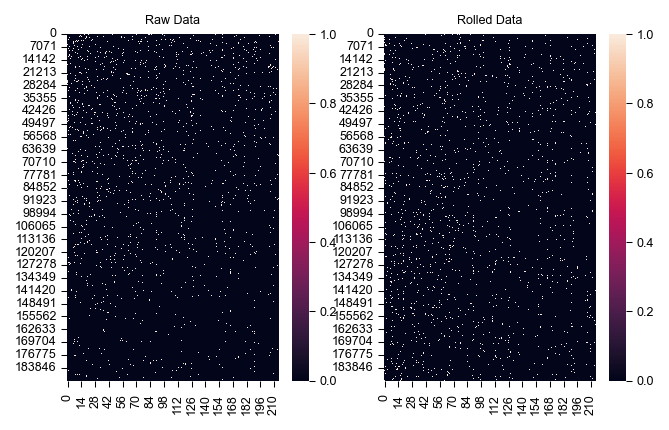

In [273]:
fig, axes = plt.subplots(1, 2, figsize=(5, 3))
sns.heatmap(ax = axes[0], data = raster_df.loc[:, cell_col].values)
axes[0].set_title('Raw Data')


data = raster_df.loc[:, cell_col].values
roll_data = random_roll_columns(data)

sns.heatmap(ax = axes[1], data = roll_data)
axes[1].set_title('Rolled Data')

plt.show()


In [201]:
def get_mean_postoutcome_stage_activity(input_df, cell_col, label_col='task_stage', section_col = 'trial_section', post_outcome_label='post_outcome'):
    """ For groupby operation that returns mean activity for post-outcome stage of each cell in each section """
    mean_section_stage_act = input_df.groupby(by = [label_col, section_col])[cell_col].mean() #325 ms
    return mean_section_stage_act.loc[(slice(None),post_outcome_label),:]    

In [274]:
%%timeit
def create_shuffled_df(args):
    """Helper function for parallel processing"""
    df, cell_col, random_seed = args
    roll_data = random_roll_columns(df[cell_col].values, random_seed= random_seed)
    rolled_df = pd.DataFrame(roll_data, columns=cell_col, index=raster_df.index).join(raster_df.drop(columns = cell_col))
    mean_section_stage_act = get_mean_postoutcome_stage_activity(rolled_df, cell_col)
    return mean_section_stage_act

# 1s per shuffle is current speed
create_shuffled_df((raster_df, cell_col, None))

1.31 s ± 70.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [275]:
# %%timeit
# Without unique seeds
def process(i, seed):
    rng = np.random.default_rng(seed)
    return rng.integers(0, 100, 3)

# All processes get the same seed
results = [process(i, 42) for i in range(3)]
results

[array([ 8, 77, 65], dtype=int64),
 array([ 8, 77, 65], dtype=int64),
 array([ 8, 77, 65], dtype=int64)]

In [256]:
results = [process(i, i) for i in range(3)]
print(results)
results = [process(i, 1) for i in range(3)]
print(results)

[array([85, 63, 51], dtype=int64), array([47, 51, 75], dtype=int64), array([83, 26, 10], dtype=int64)]
[array([47, 51, 75], dtype=int64), array([47, 51, 75], dtype=int64), array([47, 51, 75], dtype=int64)]


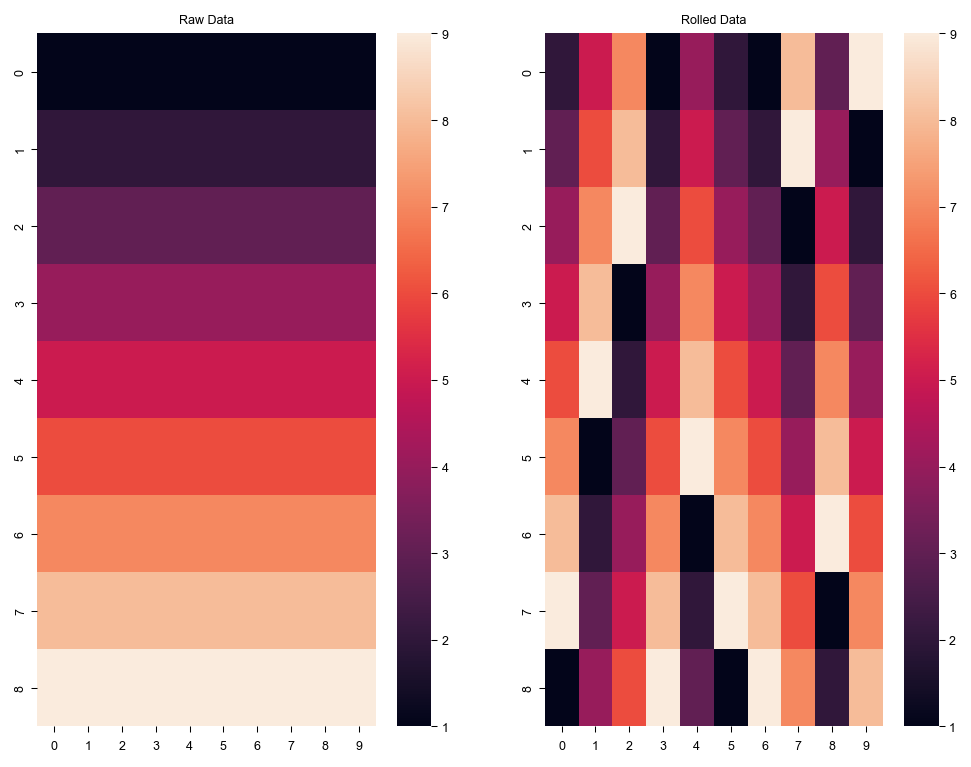

In [218]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6))
sns.heatmap(ax = axes[0], data = mat)
axes[0].set_title('Raw Data')

sns.heatmap(ax = axes[1], data = rolled)
axes[1].set_title('Rolled Data')

plt.show()


In [187]:
metadata_cols = [c for c in raster_df.columns if c not in cell_col]
metadata_cols

['labels',
 'subject_name',
 'geno',
 'session',
 'trial_num',
 'task_stage',
 'trial_section']

In [191]:
import time
# Let's time each part separately
def profile_operation():
    # Time column access
    t0 = time.time()
    data = raster_df[cell_col].values
    t1 = time.time()
    print(f"Column access: {(t1-t0)*1000:.2f}ms")
    
    # Time the rolling operation
    roll_data = random_roll_columns(data)
    t2 = time.time()
    print(f"Rolling: {(t2-t1)*1000:.2f}ms")
    
    # Time DataFrame construction
    df = pd.DataFrame(roll_data, columns=cell_col, index=raster_df.index)
    t3 = time.time()
    print(f"DataFrame creation: {(t3-t2)*1000:.2f}ms")
    
    # Time the join
    result = df.join(raster_df.drop(columns=cell_col))
    t4 = time.time()
    print(f"Join: {(t4-t3)*1000:.2f}ms")
    print(f"Total: {(t4-t0)*1000:.2f}ms")
    
    return result

# Run the profiler
_ = profile_operation()

Column access: 82.00ms
Rolling: 503.86ms
DataFrame creation: 0.00ms
Join: 390.42ms
Total: 976.28ms


In [ ]:

def circular_shuffle_mean_activity_vectorized(raster_df, category_value, label_col='task_stage', 
                                               n_shuffles=1000, random_seed=None):
    """    Advanced vectorized implementation - processes multiple shuffles more efficiently.
    """
    # Set random seed if provided
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Convert to numpy arrays
    cell_col = [c for c in raster_df.columns if 'cell' in c] #select all columns that contain 'cell'
    
    if hasattr(raster_df[cell_col], 'sparse'):
        activity = raster_df[cell_col].sparse.to_dense().values.astype(np.float64)
    else:
        activity = raster_df[cell_col].values.astype(np.float64)
    
    labels = raster_df[label_col].values
    n_total_frames = len(labels)
    
    # Compute observed mean
    #note, you need to calculate real activity in TRIAL SECTION x Task Stage specifically
    observed_mask = (labels == category_value)
    observed_mean = activity[observed_mask].mean()
    n_frames_observed = observed_mask.sum()
    
    # + create matrix (n_cells x N_shuffles), where elem at (i,j) = random frame offset for cell i at shuffle j 
    # + for each shuffle, apply offset to (frame labels of interest) vector, with cells having independent offsets 
    # + for each cell, calculate mean activity in offset frames 

    # Generate all random shifts at once
    #note, in MATLAB script, circularly shifted across entire matrix, not trial sections of interest
    #note- each cell gets its own random shift
    shifts = np.random.randint(low = 1, high = n_frames, size=(1, n_shuffles)) #(low, high=None, size=None, dtype=int)
    
    # Pre-allocate
    shuffled_means = np.empty(n_shuffles, dtype=np.float64)
    
    # Process shuffles
    for i, shift in enumerate(shifts):
        shuffled_labels = np.roll(labels, shift)
        shuffled_mask = (shuffled_labels == category_value)
        shuffled_means[i] = activity[shuffled_mask].mean()
    
    p_value = (shuffled_means >= observed_mean).sum() / n_shuffles
    
    return {
        'observed_mean': observed_mean,
        'shuffled_means': shuffled_means,
        'p_value': p_value,
        'n_frames_in_category': n_frames_observed,
        'shuffle_distribution_mean': shuffled_means.mean(),
        'shuffle_distribution_std': shuffled_means.std()
    }

In [28]:
print(observed_mask.shape)
print(n_frames_observed)

(190893,)
11780


In [29]:
observed_mean

0.032851502349271526

In [ ]:
### Performance Comparison: Standard vs Vectorized (with controlled RNG)

import time

# Select test data
test_subject = '10_3_HET_RS1'
test_raster = raster_dataframes[test_subject]
test_cell = 'cell_5'
test_category = 'Early_IA_Correct'
n_test_shuffles = 1000

print("Performance Comparison (1000 shuffles):")
print("=" * 60)

# Test 2: Vectorized version (same seed)
np.random.seed(42)  # Same seed for fair comparison
start = time.time()
result_vectorized = circular_shuffle_mean_activity_vectorized(test_raster, test_cell, test_category, n_shuffles=n_test_shuffles
)
time_vectorized = time.time() - start
print(f"\nVectorized:  {time_vectorized:.3f}s  (Speedup: {time_standard/time_vectorized:.2f}x)")
print(f"  - Observed mean: {result_vectorized['observed_mean']:.4f}")
print(f"  - P-value: {result_vectorized['p_value']:.4f}")

print("\n" + "=" * 60)
print(f"Observed means match: {np.allclose(result_standard['observed_mean'], result_vectorized['observed_mean'])}")
print(f"P-values match (same seed): {np.allclose(result_standard['p_value'], result_vectorized['p_value'])}")
print(f"Shuffle distributions match: {np.allclose(result_standard['shuffled_means'], result_vectorized['shuffled_means'])}")

# Demonstrate that different seeds give different p-values (as expected)
print("\n" + "=" * 60)
print("Demonstration: Different random seeds give different p-values")
print("=" * 60)
np.random.seed(123)
result_seed1 = circular_shuffle_mean_activity_vectorized(test_raster, test_cell, test_category, n_shuffles=1000)
np.random.seed(456)
result_seed2 = circular_shuffle_mean_activity_vectorized(test_raster, test_cell, test_category, n_shuffles=1000)
print(f"Seed 123 p-value: {result_seed1['p_value']:.4f}")
print(f"Seed 456 p-value: {result_seed2['p_value']:.4f}")
print(f"Difference: {abs(result_seed1['p_value'] - result_seed2['p_value']):.4f}")
print(f"\n✓ This variability is normal - use more shuffles (e.g., 10,000) for stable p-values")

Performance Comparison (1000 shuffles):
Standard:    2.179s
Vectorized:  2.313s  (Speedup: 0.94x)

Results are consistent: True

Observed mean: 0.0681
P-value (standard): 0.0840
P-value (vectorized): 0.1040


In [ ]:
# Example: Circular shuffle analysis for a single cell
# Select a dataset and cell to analyze
example_subject = '10_3_HET_RS1'
example_raster = raster_dataframes[example_subject]
example_cell = 'cell_5'
example_category = 'Early_IA_Correct'

# Run circular shuffle analysis
results = circular_shuffle_mean_activity_vectorized(
    raster_df=example_raster,
    cell_col=example_cell,
    category_value=example_category,
    label_col='task_stage',
    n_shuffles=1000
)

# Display results
print(f"Subject: {example_subject}")
print(f"Cell: {example_cell}")
print(f"Category: {example_category}")
print(f"Observed mean activity: {results['observed_mean']:.4f}")
print(f"Shuffled mean (avg): {results['shuffle_distribution_mean']:.4f} ± {results['shuffle_distribution_std']:.4f}")
print(f"P-value: {results['p_value']:.4f}")
print(f"Frames in category: {results['n_frames_in_category']}")

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(results['shuffled_means'], bins=50, alpha=0.7, edgecolor='black', label='Shuffled distribution')
ax.axvline(results['observed_mean'], color='red', linestyle='--', linewidth=2, label=f'Observed mean = {results["observed_mean"]:.4f}')
ax.set_xlabel('Mean Activity')
ax.set_ylabel('Frequency')
ax.set_title(f'Circular Shuffle Distribution: {example_subject} - {example_cell} - {example_category}')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
### Batch Analysis with Parallel Processing

def batch_circular_shuffle_analysis(raster_df, cell_cols, categories, label_col='task_stage', 
                                     n_shuffles=1000, use_vectorized=True, parallel=False, n_jobs=-1):
    """
    Run circular shuffle analysis for multiple cells and categories.
    
    Parameters
    ----------
    raster_df : pd.DataFrame
        DataFrame with frame-level data
    cell_cols : list of str
        List of cell column names to analyze
    categories : list of str
        List of categories to test
    label_col : str
        Column containing categorical labels
    n_shuffles : int
        Number of shuffles per test
    use_vectorized : bool, default=True
        Use vectorized version for better performance
    parallel : bool, default=False
        Use parallel processing across cells (requires joblib)
    n_jobs : int, default=-1
        Number of parallel jobs (-1 = use all cores)
    
    Returns
    -------
    pd.DataFrame
        Results table with one row per cell-category combination
    """
    # Select function
    shuffle_func = circular_shuffle_mean_activity_vectorized if use_vectorized else circular_shuffle_mean_activity
    
    def _analyze_one(cell_col, category):
        """Helper function for one cell-category combination"""
        result = shuffle_func(
            raster_df=raster_df,
            cell_col=cell_col,
            category_value=category,
            label_col=label_col,
            n_shuffles=n_shuffles
        )
        
        return {
            'cell': cell_col,
            'category': category,
            'observed_mean': result['observed_mean'],
            'shuffle_mean': result['shuffle_distribution_mean'],
            'shuffle_std': result['shuffle_distribution_std'],
            'p_value': result['p_value'],
            'n_frames': result['n_frames_in_category'],
            'significant_05': result['p_value'] < 0.05,
            'significant_01': result['p_value'] < 0.01
        }
    
    if parallel:
        # Parallel processing
        try:
            from joblib import Parallel, delayed
            
            # Create all combinations
            tasks = [(cell, cat) for cell in cell_cols for cat in categories]
            
            print(f"Running {len(tasks)} analyses in parallel with {n_jobs} jobs...")
            results_list = Parallel(n_jobs=n_jobs)(
                delayed(_analyze_one)(cell, cat) for cell, cat in tasks
            )
        except ImportError:
            print("Warning: joblib not installed. Falling back to sequential processing.")
            print("Install with: pip install joblib")
            parallel = False
    
    if not parallel:
        # Sequential processing
        results_list = []
        total = len(cell_cols) * len(categories)
        for idx, cell_col in enumerate(cell_cols):
            for category in categories:
                results_list.append(_analyze_one(cell_col, category))
            
            if (idx + 1) % 10 == 0 or (idx + 1) == len(cell_cols):
                print(f"  Progress: {(idx + 1) * len(categories)}/{total} tests completed", end='\r')
        print()  # New line after progress
    
    return pd.DataFrame(results_list)


# Example: Compare sequential vs parallel
example_subject = '10_3_HET_RS1'
example_raster = raster_dataframes[example_subject]
cell_cols_test = [col for col in example_raster.columns if col.startswith('cell_')][:20]

print("Testing batch analysis speed...")
print(f"Analyzing {len(cell_cols_test)} cells × {len(stage_names)} categories = {len(cell_cols_test) * len(stage_names)} tests")
print()

# Sequential
start = time.time()
results_sequential = batch_circular_shuffle_analysis(
    raster_df=example_raster,
    cell_cols=cell_cols_test,
    categories=stage_names,
    n_shuffles=1000,
    use_vectorized=True,
    parallel=False
)
time_sequential = time.time() - start
print(f"\nSequential: {time_sequential:.2f}s")

# Parallel (if joblib available)
try:
    import joblib
    start = time.time()
    results_parallel = batch_circular_shuffle_analysis(
        raster_df=example_raster,
        cell_cols=cell_cols_test,
        categories=stage_names,
        n_shuffles=1000,
        use_vectorized=True,
        parallel=True,
        n_jobs=-1
    )
    time_parallel = time.time() - start
    print(f"Parallel:   {time_parallel:.2f}s  (Speedup: {time_sequential/time_parallel:.2f}x)")
    print(f"\n✓ Using parallel processing for better performance")
except ImportError:
    print("Parallel:   Not available (install with: pip install joblib)")
    print(f"\nℹ Consider installing joblib for additional speedup on multi-core systems")

print(f"\nSignificant results (p<0.05): {results_sequential['significant_05'].sum()}")
results_sequential.sort_values('p_value').head(10)

### Circular Shuffle Analysis Across All Subjects

The code below runs the circular shuffle analysis across all subjects. 
This may take significant time - consider running on a subset first or using multiprocessing.

In [ ]:
# Run circular shuffle analysis across all subjects
# WARNING: This can take a long time! Consider testing on a subset first

def run_all_subjects_shuffle_analysis(raster_dataframes, categories, n_shuffles=1000, max_cells_per_subject=None):
    """
    Run circular shuffle analysis across all subjects.
    
    Parameters
    ----------
    raster_dataframes : dict
        Dictionary of {subject_name: raster_df}
    categories : list of str
        Task stages to analyze
    n_shuffles : int
        Number of shuffles per test
    max_cells_per_subject : int or None
        If specified, limit analysis to first N cells per subject
    
    Returns
    -------
    pd.DataFrame
        Combined results for all subjects
    """
    all_results = []
    
    for subject_idx, (subject_name, raster_df) in enumerate(raster_dataframes.items(), 1):
        print(f"Processing {subject_idx}/{len(raster_dataframes)}: {subject_name}")
        
        # Get cell columns
        cell_cols = [col for col in raster_df.columns if col.startswith('cell_')]
        if max_cells_per_subject:
            cell_cols = cell_cols[:max_cells_per_subject]
        
        # Run batch analysis
        subject_results = batch_circular_shuffle_analysis(
            raster_df=raster_df,
            cell_cols=cell_cols,
            categories=categories,
            label_col='task_stage',
            n_shuffles=n_shuffles
        )
        
        # Add subject metadata
        subject_results['subject'] = subject_name
        subject_results['geno'] = raster_df['geno'].iloc[0]
        subject_results['session'] = raster_df['session'].iloc[0]
        
        all_results.append(subject_results)
        print(f"  Completed {len(cell_cols)} cells × {len(categories)} categories = {len(subject_results)} tests")
    
    return pd.concat(all_results, ignore_index=True)

# Example: Run on first 3 subjects with first 5 cells each
# Uncomment to run:
# test_subjects = dict(list(raster_dataframes.items())[:3])
# test_results = run_all_subjects_shuffle_analysis(
#     raster_dataframes=test_subjects,
#     categories=stage_names,
#     n_shuffles=1000,
#     max_cells_per_subject=5
# )
# 
# # Save results
# output_file = storage_folder_name / f"circular_shuffle_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.parquet"
# test_results.to_parquet(output_file)
# print(f"Results saved to: {output_file}")
# 
# # Summary statistics
# print(f"\nSummary:")
# print(f"Total tests: {len(test_results)}")
# print(f"Significant at p<0.05: {test_results['significant_05'].sum()} ({100*test_results['significant_05'].mean():.1f}%)")
# print(f"Significant at p<0.01: {test_results['significant_01'].sum()} ({100*test_results['significant_01'].mean():.1f}%)")

print("Ready to run circular shuffle analysis. Uncomment code above to execute.")

In [ ]:
### Run Analysis Across All Subjects

def run_all_subjects_shuffle_analysis(raster_dataframes, categories, n_shuffles=1000, 
                                       max_cells_per_subject=None, use_vectorized=True, 
                                       parallel_within_subject=True, parallel_across_subjects=False):
    """
    Run circular shuffle analysis across all subjects with performance optimizations.
    
    Parameters
    ----------
    raster_dataframes : dict
        Dictionary of {subject_name: raster_df}
    categories : list of str
        Task stages to analyze
    n_shuffles : int
        Number of shuffles per test
    max_cells_per_subject : int or None
        Limit analysis to first N cells per subject
    use_vectorized : bool
        Use vectorized version for better performance
    parallel_within_subject : bool
        Parallelize across cells within each subject
    parallel_across_subjects : bool
        Parallelize across subjects (can use more memory)
    
    Returns
    -------
    pd.DataFrame
        Combined results for all subjects
    """
    
    def _process_subject(subject_name, raster_df):
        """Process one subject"""
        # Get cell columns
        cell_cols = [col for col in raster_df.columns if col.startswith('cell_')]
        if max_cells_per_subject:
            cell_cols = cell_cols[:max_cells_per_subject]
        
        # Run batch analysis
        subject_results = batch_circular_shuffle_analysis(
            raster_df=raster_df,
            cell_cols=cell_cols,
            categories=categories,
            label_col='task_stage',
            n_shuffles=n_shuffles,
            use_vectorized=use_vectorized,
            parallel=parallel_within_subject
        )
        
        # Add subject metadata
        subject_results['subject'] = subject_name
        subject_results['geno'] = raster_df['geno'].iloc[0]
        subject_results['session'] = raster_df['session'].iloc[0]
        
        return subject_results, len(cell_cols)
    
    if parallel_across_subjects:
        # Parallel across subjects (uses more memory)
        try:
            from joblib import Parallel, delayed
            
            print(f"Processing {len(raster_dataframes)} subjects in parallel...")
            results = Parallel(n_jobs=-1)(
                delayed(_process_subject)(name, df) 
                for name, df in raster_dataframes.items()
            )
            all_results = [r[0] for r in results]
        except ImportError:
            print("Warning: joblib not installed, using sequential processing")
            parallel_across_subjects = False
    
    if not parallel_across_subjects:
        # Sequential across subjects (more memory-efficient)
        all_results = []
        
        for subject_idx, (subject_name, raster_df) in enumerate(raster_dataframes.items(), 1):
            print(f"\nProcessing {subject_idx}/{len(raster_dataframes)}: {subject_name}")
            
            subject_results, n_cells = _process_subject(subject_name, raster_df)
            all_results.append(subject_results)
            
            print(f"  ✓ Completed {n_cells} cells × {len(categories)} categories = {len(subject_results)} tests")
    
    combined = pd.concat(all_results, ignore_index=True)
    
    # Summary statistics
    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE")
    print("=" * 60)
    print(f"Total subjects: {combined['subject'].nunique()}")
    print(f"Total tests: {len(combined):,}")
    print(f"Significant at p<0.05: {combined['significant_05'].sum():,} ({100*combined['significant_05'].mean():.1f}%)")
    print(f"Significant at p<0.01: {combined['significant_01'].sum():,} ({100*combined['significant_01'].mean():.1f}%)")
    
    return combined


# ========== RECOMMENDED WORKFLOW ==========

# STEP 1: Quick test on subset (recommended first step)
print("STEP 1: Quick Test on Subset")
print("-" * 60)
test_subjects = dict(list(raster_dataframes.items())[:2])
quick_results = run_all_subjects_shuffle_analysis(
    raster_dataframes=test_subjects,
    categories=stage_names,
    n_shuffles=1000,
    max_cells_per_subject=10,  # Just 10 cells per subject
    use_vectorized=True,
    parallel_within_subject=True,
    parallel_across_subjects=False
)

# Save quick results
quick_output = storage_folder_name / f"circular_shuffle_QUICK_TEST_{datetime.now().strftime('%Y%m%d_%H%M%S')}.parquet"
quick_results.to_parquet(quick_output)
print(f"\nQuick test results saved to: {quick_output}")
quick_results.groupby('category')['significant_05'].agg(['sum', 'mean']).round(3)

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.